In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar

# =========================
# Load data
# =========================
#df = pd.read_csv(
#    r'C:\Users\mateo\ncaaBaseballDraft-Predictor\CSV+Code Files\pythagorean_expectation\ncaabb_teamStats.csv'
#)
df = pd.read_csv(
    'ncaabb_teamStats.csv'
)

df = df.rename(columns={
    'R (Batting)': 'R',
    'R (Pitching)': 'RA'
})

df = df[
    (df['R'] > 0) &
    (df['RA'] > 0) &
    (~df['WPCT'].isna()) &
    (df['G'] >= 20)
].copy()

# =========================
# Pythagorean model
# =========================
def pythag_wpct(R, RA, gamma):
    return (R ** gamma) / (R ** gamma + RA ** gamma)

def r2_gamma(gamma, R, RA, WPCT):
    y_hat = pythag_wpct(R, RA, gamma)
    ss_res = np.sum((WPCT - y_hat) ** 2)
    ss_tot = np.sum((WPCT - WPCT.mean()) ** 2)
    return 1 - ss_res / ss_tot

# =========================
# Optimal gamma (ALL TEAMS)
# =========================
opt_all = minimize_scalar(
    lambda g: -r2_gamma(g, df['R'], df['RA'], df['WPCT']),
    bounds=(0.5, 4),
    method='bounded'
)

gamma_hat = opt_all.x
r2_opt = r2_gamma(gamma_hat, df['R'], df['RA'], df['WPCT'])

r2_183 = r2_gamma(1.83, df['R'], df['RA'], df['WPCT'])
r2_200 = r2_gamma(2.00, df['R'], df['RA'], df['WPCT'])

print("=== ALL TEAMS ===")
print(f"Optimal gamma: {gamma_hat:.4f}")
print(f"R^2 (optimal): {r2_opt:.6f}")
print(f"R^2 (1.83):    {r2_183:.6f}")
print(f"R^2 (2.00):    {r2_200:.6f}")

# =========================
# R^2-based confidence bounds
# =========================
# Rule: exponents within 0.001 of max R^2 are practically indistinguishable
# (standard sabermetric convention)

r2_tol = 0.001
gamma_grid = np.arange(1.2, 2.5, 0.001)

r2_grid = np.array([
    r2_gamma(g, df['R'], df['RA'], df['WPCT'])
    for g in gamma_grid
])

ci_lower = gamma_grid[r2_grid >= r2_opt - r2_tol].min()
ci_upper = gamma_grid[r2_grid >= r2_opt - r2_tol].max()

print(f"R^2-equivalent gamma range: [{ci_lower:.3f}, {ci_upper:.3f}]")

# =========================
# Conference-level results
# =========================
conference_results = []

for league, gdf in df.groupby('league'):
    if len(gdf) < 50:
        continue

    opt = minimize_scalar(
        lambda g: -r2_gamma(g, gdf['R'], gdf['RA'], gdf['WPCT']),
        bounds=(0.5, 4),
        method='bounded'
    )

    gamma_hat_c = opt.x
    r2_opt_c = r2_gamma(gamma_hat_c, gdf['R'], gdf['RA'], gdf['WPCT'])

    r2_grid_c = np.array([
        r2_gamma(g, gdf['R'], gdf['RA'], gdf['WPCT'])
        for g in gamma_grid
    ])

    ci_l = gamma_grid[r2_grid_c >= r2_opt_c - r2_tol].min()
    ci_u = gamma_grid[r2_grid_c >= r2_opt_c - r2_tol].max()

    conference_results.append({
        'league': league,
        'gamma_hat': gamma_hat_c,
        'r2': r2_opt_c,
        'ci_lower': ci_l,
        'ci_upper': ci_u,
        'n_obs': len(gdf)
    })

conference_df = pd.DataFrame(conference_results).sort_values('gamma_hat')

print("\n=== CONFERENCE RESULTS ===")
conference_df


=== ALL TEAMS ===
Optimal gamma: 1.7510
R^2 (optimal): 0.892807
R^2 (1.83):    0.891448
R^2 (2.00):    0.879763
R^2-equivalent gamma range: [1.685, 1.818]

=== CONFERENCE RESULTS ===


,league,gamma_hat,r2,ci_lower,ci_upper,n_obs
4,Big 12,1.571258,0.789272,1.529,1.614,217
12,Independent,1.647127,0.899033,1.589,1.707,57
23,SEC,1.662591,0.837781,1.620,1.705,290
24,SWAC,1.676719,0.901115,1.618,1.736,228
29,The American,1.678760,0.847468,1.620,1.738,211
26,Southland,1.686257,0.856402,1.625,1.748,241
9,CAA,1.700464,0.878364,1.639,1.763,222
22,Patriot,1.703947,0.820879,1.643,1.766,132
0,ACC,1.716805,0.887331,1.667,1.768,284
7,Big Ten,1.724248,0.827739,1.661,1.788,257


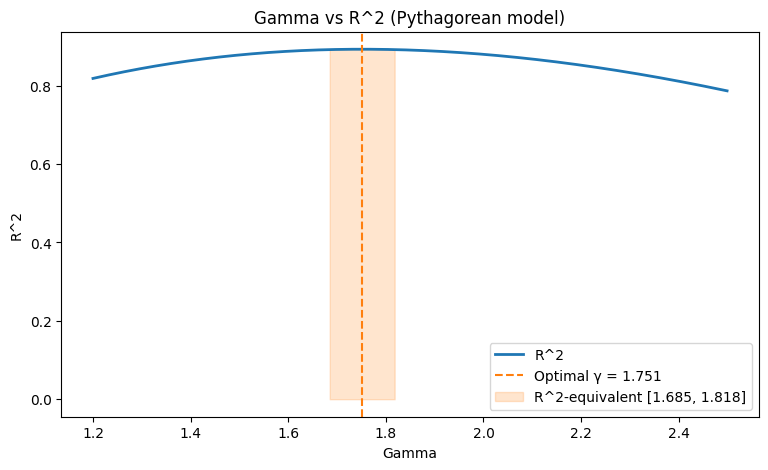

In [5]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# recompute grid & R^2 (safe if variables not in scope)
gamma_grid = np.arange(1.2, 2.5, 0.001)
r2_grid = np.array([r2_gamma(g, df['R'], df['RA'], df['WPCT']) for g in gamma_grid])

opt = minimize_scalar(lambda g: -r2_gamma(g, df['R'], df['RA'], df['WPCT']), bounds=(0.5, 4), method='bounded')
gamma_hat = opt.x
r2_opt = r2_gamma(gamma_hat, df['R'], df['RA'], df['WPCT'])
r2_tol = 0.001
ci_lower = gamma_grid[r2_grid >= r2_opt - r2_tol].min()
ci_upper = gamma_grid[r2_grid >= r2_opt - r2_tol].max()

plt.figure(figsize=(9,5))
plt.plot(gamma_grid, r2_grid, lw=2, label='R^2')
plt.axvline(gamma_hat, color='C1', ls='--', label=f'Optimal γ = {gamma_hat:.3f}')
plt.fill_between(gamma_grid, r2_grid, where=(gamma_grid >= ci_lower) & (gamma_grid <= ci_upper), color='C1', alpha=0.2, label=f'R^2-equivalent [{ci_lower:.3f}, {ci_upper:.3f}]')
plt.xlabel('Gamma')
plt.ylabel('R^2')
plt.title('Gamma vs R^2 (Pythagorean model)')
plt.legend()
plt.show()

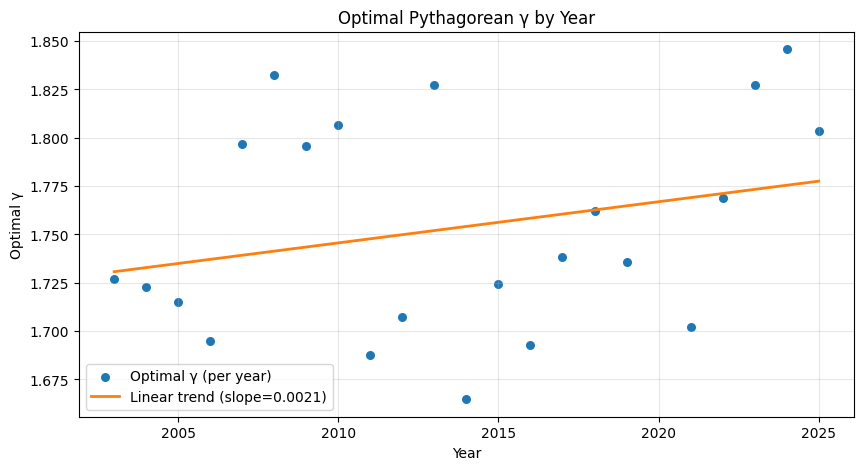

In [6]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# compute optimal gamma per year (require >=10 teams per year)
year_results = []
for year, ydf in df.groupby('year'):
    if len(ydf) < 10:
        continue
    opt = minimize_scalar(
        lambda g: -r2_gamma(g, ydf['R'], ydf['RA'], ydf['WPCT']),
        bounds=(0.5, 4), method='bounded'
    )
    year_results.append({'year': int(year), 'gamma': opt.x, 'n': len(ydf)})

year_df = pd.DataFrame(year_results).sort_values('year')

# linear trend
z = np.polyfit(year_df['year'], year_df['gamma'], 1)
p = np.poly1d(z)

plt.figure(figsize=(10,5))
plt.scatter(year_df['year'], year_df['gamma'], s=30, c='C0', label='Optimal γ (per year)')
plt.plot(year_df['year'], p(year_df['year']), color='C1', lw=2, label=f'Linear trend (slope={z[0]:.4f})')
plt.xlabel('Year')
plt.ylabel('Optimal γ')
plt.title('Optimal Pythagorean γ by Year')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar

# =========================
# Load data
# =========================
#df = pd.read_csv(
#    r'C:\Users\mateo\ncaaBaseballDraft-Predictor\CSV+Code Files\pythagorean_expectation\ncaabb_teamStats.csv'
#)
df = pd.read_csv(
    'ncaabb_teamStats.csv'
)

df = df.rename(columns={
    'R (Batting)': 'R',
    'R (Pitching)': 'RA'
})

df = df[
    (df['R'] > 0) &
    (df['RA'] > 0) &
    (~df['WPCT'].isna()) &
    (df['G'] >= 20)
].copy()

# =========================
# Pythagorean model
# =========================
def pythag_wpct(R, RA, gamma):
    return (R ** gamma) / (R ** gamma + RA ** gamma)

def r2_gamma(gamma, R, RA, WPCT):
    y_hat = pythag_wpct(R, RA, gamma)
    ss_res = np.sum((WPCT - y_hat) ** 2)
    ss_tot = np.sum((WPCT - WPCT.mean()) ** 2)
    return 1 - ss_res / ss_tot

# =========================
# Global optimal gamma
# =========================
opt_all = minimize_scalar(
    lambda g: -r2_gamma(g, df['R'], df['RA'], df['WPCT']),
    bounds=(0.5, 4),
    method='bounded'
)

gamma_hat_global = opt_all.x
r2_global = r2_gamma(gamma_hat_global, df['R'], df['RA'], df['WPCT'])

# =========================
# Conference-level gammas
# =========================
league_gamma = {}

for league, gdf in df.groupby('league'):
    if len(gdf) < 50:
        continue

    opt = minimize_scalar(
        lambda g: -r2_gamma(g, gdf['R'], gdf['RA'], gdf['WPCT']),
        bounds=(0.5, 4),
        method='bounded'
    )

    league_gamma[league] = opt.x

# =========================
# Example team (reproducible)
# =========================
np.random.seed(1)
example_idx = np.random.choice(df.index)
team_row = df.loc[example_idx]

team_R = team_row['R']
team_RA = team_row['RA']
team_WPCT = team_row['WPCT']
team_league = team_row['league']
team_name = team_row['team']
team_year = team_row['year']
team_G = int(team_row['G'])
team_W = int(team_row['W'])
team_L = int(team_row['L'])

# =========================
# Predicted WPCTs
# =========================
wpct_pred = {
    'Global optimal γ': pythag_wpct(team_R, team_RA, gamma_hat_global),
    'League γ': pythag_wpct(team_R, team_RA, league_gamma.get(team_league, gamma_hat_global)),
    'γ = 1.83': pythag_wpct(team_R, team_RA, 1.83),
    'γ = 2.00': pythag_wpct(team_R, team_RA, 2.00)
}

# =========================
# Convert WPCT → W–L
# =========================
wl_pred = {}

for model, wp in wpct_pred.items():
    wins = wp * team_G
    losses = team_G - wins
    wl_pred[model] = f"{wins:.1f}–{losses:.1f}"

# =========================
# R^2 comparison (full data)
# =========================
r2_comparison = {
    'Global optimal γ': r2_gamma(gamma_hat_global, df['R'], df['RA'], df['WPCT']),
    'League γ': r2_gamma(
        league_gamma.get(team_league, gamma_hat_global),
        df['R'], df['RA'], df['WPCT']
    ),
    'γ = 1.83': r2_gamma(1.83, df['R'], df['RA'], df['WPCT']),
    'γ = 2.00': r2_gamma(2.00, df['R'], df['RA'], df['WPCT'])
}

# =========================
# Output table
# =========================
pred_wins = [wp * team_G for wp in wpct_pred.values()]                    # numeric predicted wins
pred_wl_formatted = [f"{pw:.1f}–{(team_G - pw):.1f}" for pw in pred_wins]  # formatted W–L
win_diff = [pw - team_W for pw in pred_wins]                              # predicted - actual wins

example_df = pd.DataFrame({
    'Model': list(wpct_pred.keys()),
    'Predicted WPCT': list(wpct_pred.values()),
    'Predicted W–L': pred_wl_formatted,
    'Predicted Wins': [round(pw, 1) for pw in pred_wins],
    'Win Diff (Pred - Actual)': [round(d, 1) for d in win_diff],
    'R^2 (full dataset)': list(r2_comparison.values())
})

print("=== EXAMPLE TEAM ===")
print(f"Team: {team_name} ({team_year})")
print(f"League: {team_league}")
print(f"Games Played: {team_G}")
print(f"Actual Record: {team_W}–{team_L}")
print(f"Actual WPCT: {team_WPCT:.3f}")
print(f"League γ: {league_gamma.get(team_league, gamma_hat_global):.3f}")
print(f"Global γ: {gamma_hat_global:.3f}")

example_df

